In [1]:
from tensorflow.keras.layers import Conv2D
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from plotly import graph_objs as go

import tqdm

from src.green_gecko_model import CAModel, make_seed
from src.lyapunov import estimate_lyapunov_spectrum, plot_lyaps

# Calculating the Lyapunov spectrum
### Load the model

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

In [3]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model/plain_salamander/big_fire_rate1_nr3/8000.weights.h5")
None

2026-04-11 21:23:09.390717: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-11 21:23:09.390743: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-11 21:23:09.390749: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-11 21:23:09.390768: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-11 21:23:09.390787: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-11 21:23:09.798641: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Run the model with a large burn-in

In [4]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(4000):
    x = model(x)
    states.append(tf.identity(x).numpy())

states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end]

### Run the calculations

In [ ]:
# With burn in
x_star = states[-1]

tf.config.experimental.enable_op_determinism()
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)

res, lyaps = estimate_lyapunov_spectrum(
    model, x_star, k=50, steps=10000, epsilon=1e-4, 
    mode="finite_diff", ortho_mode="QR", init_mode="initializer", dynamic_epsilon=False, warm_up=100)

100%|██████████| 10100/10100 [1:51:13<00:00,  1.51it/s] 


Highest k exponents is [-0.00904116 -0.01418822 -0.01493271 -0.01506008 -0.01518952 -0.01558865
 -0.01699215 -0.01710435 -0.01760198 -0.0177511  -0.01826144 -0.01844734
 -0.02079975 -0.02118257 -0.02217778 -0.02219574 -0.0225871  -0.02306587
 -0.02448564 -0.02497986 -0.02500477 -0.02538247 -0.02569439 -0.02655417
 -0.02663575 -0.02680417 -0.02689664 -0.02706173 -0.0271135  -0.02716385
 -0.02801747 -0.02828607 -0.02833675 -0.02837372 -0.02871981 -0.02874093
 -0.02884165 -0.0288838  -0.02901982 -0.02914182 -0.02931686 -0.02947003
 -0.02953627 -0.02964435 -0.02972111 -0.03008678 -0.03022784 -0.03036826
 -0.03074648 -0.03076934]


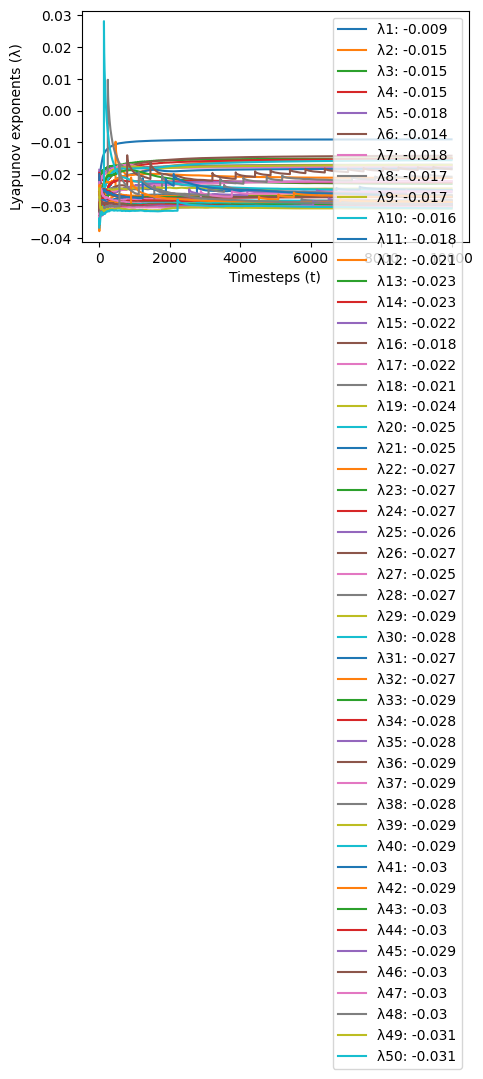

In [8]:
plot_lyaps(res, lyaps[:])
print("Highest k exponents is", res.numpy()[res.numpy().argsort()[::-1]])

As the lower values finally dip a bit, I wonder what the full spectrum looks like. This took me 2 hours, and I got 0.2% of it.